In [1]:
import eventIO
import numpy as np
import matplotlib.pyplot as plt
import cv2
import matplotlib.patches as patches

In [ ]:
events = eventIO.load_hdf5("../data/output/max/max-recording-snippet.hdf5")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../data/output/max-recording-snippet.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

/tmp/ipykernel_54583/1356440766.py:20: RuntimeWarning: invalid value encountered in cast
  img[ind] = 125 + (2 * indsurface[ind] - 1) * np.exp(-(t + tw - tsurface[ind].astype(np.float32))/ (tw/30)) * 125


(-0.5, 1279.5, 719.5, -0.5)

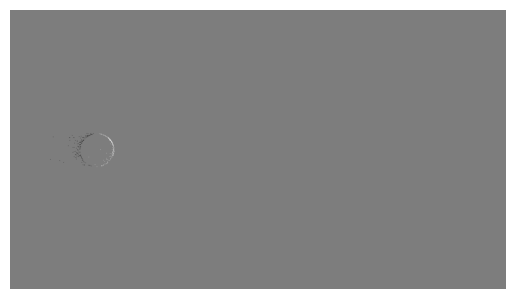

In [ ]:
ts = events.get_ts()
x = events.get_x()
y = events.get_y()
p = events.get_p()

res = [720, 1280]
tw = 50
img = np.zeros((res[0], res[1]), dtype=np.uint8)
tsurface = np.zeros((res[0], res[1]), dtype=np.uint64)
indsurface = np.zeros((res[0], res[1]), dtype=np.uint64)
image = []

for t in range(ts[0], ts[-1], tw):
    ind = np.where((ts > t)&(ts < t + tw))
    tsurface[:, :] = 0
    tsurface[y[ind], x[ind]] = t + tw
    indsurface[y[ind], x[ind]] = p[ind]
    ind = np.where(tsurface > 0)
    img[:, :] = 125
    img[ind] = 125 + (2 * indsurface[ind] - 1) * np.exp(-(t + tw - tsurface[ind].astype(np.float32))/ (tw/30)) * 125
    img_c = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    #img_c = cv2.applyColorMap(img_c, cv2.COLORMAP_VIRIDIS)

    if t > (500 * 50) + ts[0]:
        image = img_c
        break

plt.imshow(image)
plt.axis('off')

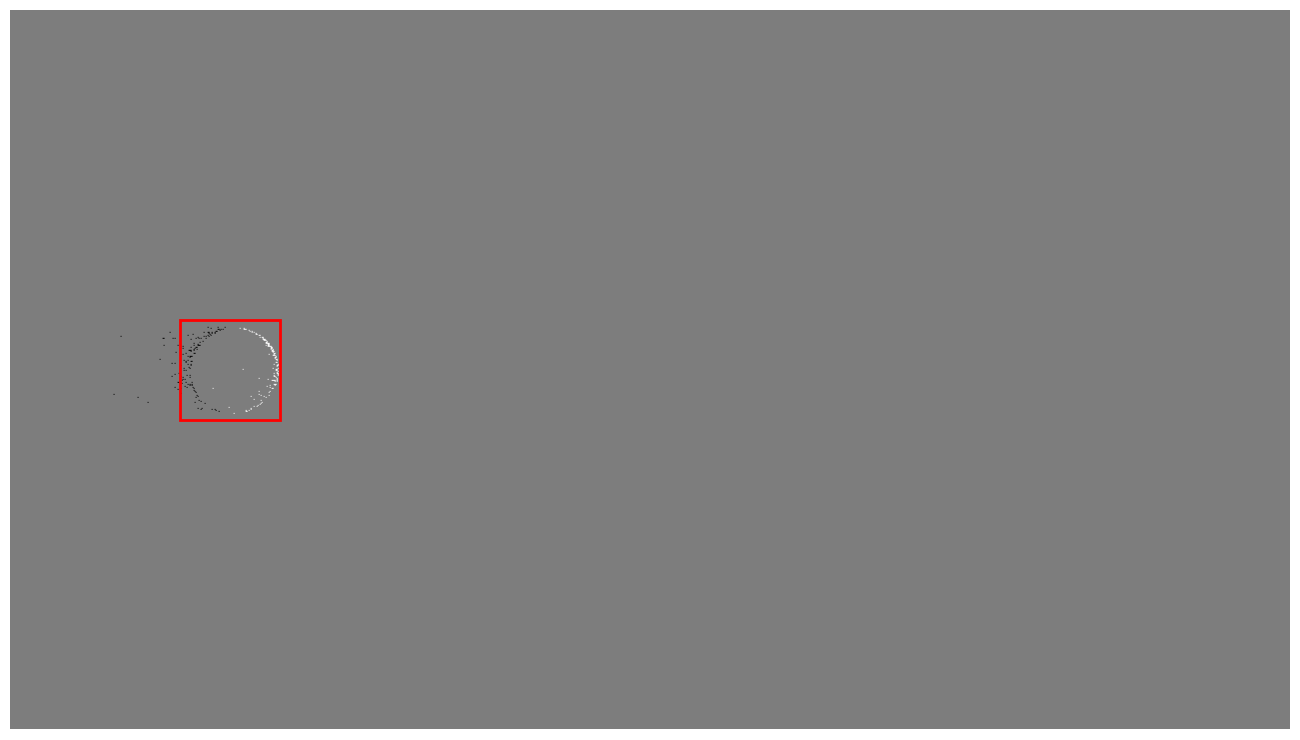

In [ ]:
canvas_width = 1280  # Width in pixels
canvas_height = 720  # Height in pixels
dpi = 100  # Dots per inch for the figure

# Create figure and axes with specified DPI
fig = plt.figure(figsize=(canvas_width / dpi, canvas_height / dpi), dpi=dpi)
ax = fig.add_axes([0, 0, 1, 1])  # fill entire figure

# Turn off axis
ax.set_axis_off()

# Set limits to match pixel coordinates
ax.set_xlim(0, canvas_width)
ax.set_ylim(0, canvas_height)
ax.invert_yaxis()  # (0,0) at top-left like in image coordinates

# Draw a red square: 100x100 pixels starting at (50, 50)
square = patches.Rectangle((170, 310), 100, 100, linewidth=2, edgecolor='red', facecolor='none')
ax.imshow(image)
ax.add_patch(square)

plt.show()

In [ ]:
rot_x = -75.897436
rot_y = -22.564103
rot_z = -10.25641

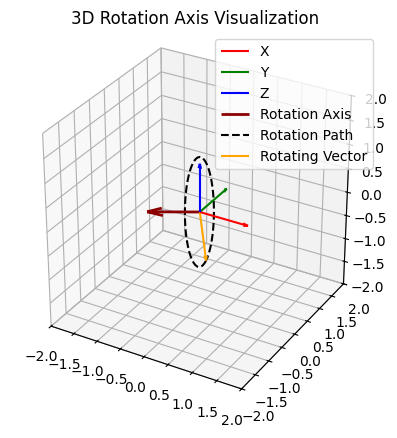

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create figure and 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot coordinate axes
origin = np.array([0, 0, 0])
ax.quiver(*origin, 1, 0, 0, color='r', label='X', arrow_length_ratio=0.1)
ax.quiver(*origin, 0, 1, 0, color='g', label='Y', arrow_length_ratio=0.1)
ax.quiver(*origin, 0, 0, 1, color='b', label='Z', arrow_length_ratio=0.1)

# Define rotation axis (e.g., diagonal in xz-plane)
# axis_direction = np.array([rot_x, rot_y, rot_z])
# debug initial rotation axis
axis_direction = np.array([44.48465075, -2.91818715, -27.99668807])
axis_direction = axis_direction / np.linalg.norm(axis_direction)  # normalize
ax.quiver(*origin, *axis_direction, color='darkred', linewidth=2, label='Rotation Axis')

# Show a rotating vector around the axis
theta = np.linspace(0, 2 * np.pi, 100)
radius = 1.0

# Find orthonormal basis around rotation axis
def orthonormal_basis(n):
    # Find a vector not parallel to n
    if abs(n[0]) < 0.9:
        a = np.array([1, 0, 0])
    else:
        a = np.array([0, 1, 0])
    u = np.cross(n, a)
    u /= np.linalg.norm(u)
    v = np.cross(n, u)
    return u, v

u, v = orthonormal_basis(axis_direction)

# Parametrize a circle around the axis
circle_points = np.array([
    origin + radius * (np.cos(t) * u + np.sin(t) * v)
    for t in theta
])
# ax.plot(circle_points[:,0], circle_points[:,1], circle_points[:,2], 'k--', label='Rotation Path')

# Plot rotating vector (point on the circle)
rotating_vector = circle_points[0] - origin
# ax.quiver(*origin, *rotating_vector, color='orange', label='Rotating Vector', arrow_length_ratio=0.1)

# Final tweaks
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])
ax.set_box_aspect([1,1,1])
ax.set_title('3D Rotation Axis Visualization')
ax.legend()

plt.show()

In [ ]:
import rotations
rot = rotations.Rotation()
rot.set_axis(rot_x, rot_y, rot_z)

In [ ]:
print(rot.get_axis())
print(rot.get_angle())
print(np.array([rot_x, rot_y, rot_z]) / np.sqrt(rot_x**2 + rot_y**2 + rot_z**2))

[-75.897436 -22.564103 -10.25641 ]
79.8420533406851
[-0.95059474 -0.28260925 -0.12845875]
